<a href="https://colab.research.google.com/github/HinaH1/Caries-Detection-In-Dental-X-Rays-Using-Computer-Vision/blob/main/YOLOv8_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gKXgpQfXZcLo2AjGBatg")
project = rf.workspace("hinas-workspace").project("tumverilerdeneme-ap2eh")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tümverilerdeneme-3 in yolov8:: 100%|██████████| 1897/1897 [00:00<00:00, 6891.54it/s]


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'tümverilerdeneme-3', 'sample_data']


In [ ]:
!ls /content/tümverilerdeneme-3

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import yaml

yaml_path = "/content/tümverilerdeneme-3/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Fix paths
data["train"] = "/content/tümverilerdeneme-3/train/images"
data["val"] = "/content/tümverilerdeneme-3/valid/images"
data["test"] = "tümverilerdeneme-3/test/images"

# Save new YAML
with open("/content/data_fixed.yaml", "w") as f:
    yaml.dump(data, f)

print(data)

{'names': ['caries'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'tumverilerdeneme-ap2eh', 'url': 'https://universe.roboflow.com/hinas-workspace/tumverilerdeneme-ap2eh/dataset/3', 'version': 3, 'workspace': 'hinas-workspace'}, 'test': 'tümverilerdeneme-3/test/images', 'train': '/content/tümverilerdeneme-3/train/images', 'val': '/content/tümverilerdeneme-3/valid/images'}


In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    img_dir = Path(f"/content/tümverilerdeneme-3/{split}/images")
    label_dir = Path(f"/content/tümverilerdeneme-3/{split}/labels")

    print(split)
    print("images:", len(list(img_dir.glob("*"))))
    print("labels:", len(list(label_dir.glob("*.txt"))))
    print("-"*30)


train
images: 757
labels: 757
------------------------------
valid
images: 95
labels: 95
------------------------------
test
images: 94
labels: 94
------------------------------


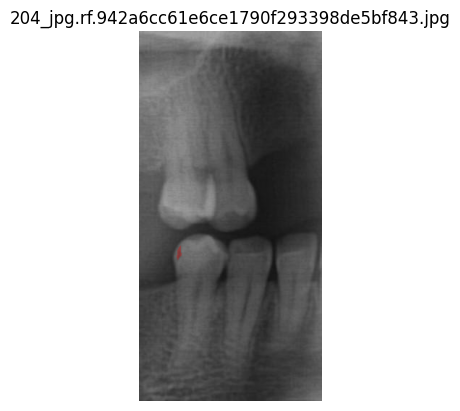

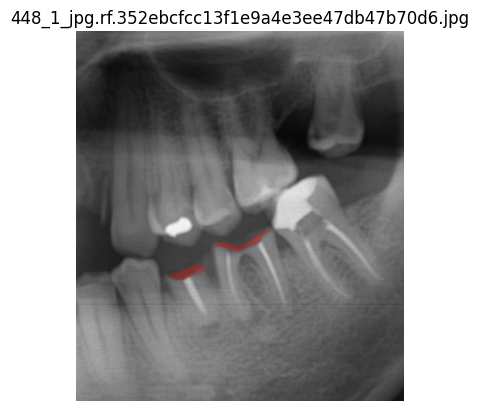

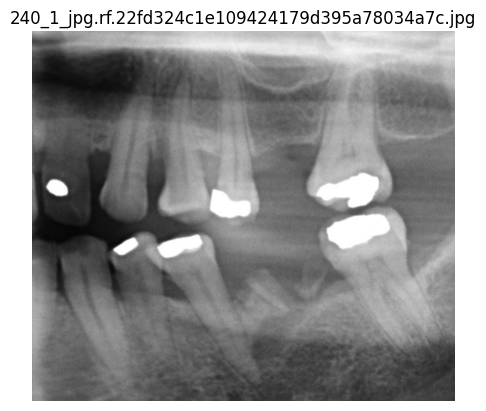

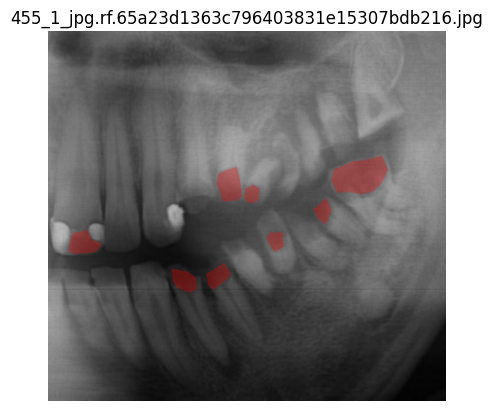

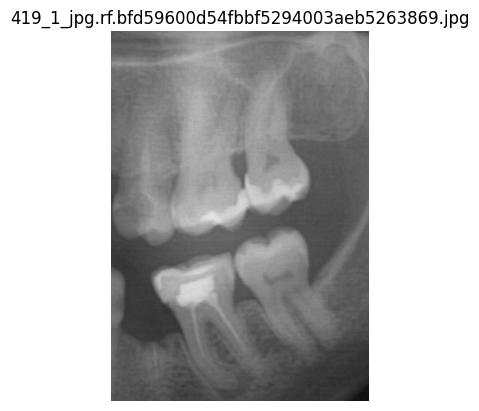

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import numpy as np

yaml_path = "/content/data_fixed.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]

img_dir = Path(data["train"])
label_dir = Path(str(img_dir).replace("/images", "/labels"))

images = list(img_dir.glob("*.jpg"))

sample = random.sample(images, min(5, len(images)))

for img_path in sample:
    label_path = label_dir / f"{img_path.stem}.txt"

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            pts = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                pts.append([x, y])

            pts = np.array(pts, dtype=np.int32)

            cv2.fillPoly(overlay, [pts], (255, 0, 0))

    out = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    plt.imshow(out)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

model.train(
    data="/content/data_fixed.yaml",
    epochs=50,
    imgsz=640,
    batch=4
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fal

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1786053e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")
model.train(
    data="/content/data_fixed.yaml",
    epochs=100,
    imgsz=768,
    batch=4,
    patience=20,
    project="/content/runs/segment",
    name="yolov8s_seg_improved"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=Fa

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e068579fd40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 